In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Задание 1

In [6]:
df = pd.read_csv('train.csv')

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Задание 2

In [8]:
# Количество строк и столбцов
print("Размер датасета (строки, столбцы):", df.shape)

# Названия всех столбцов
print("\nСтолбцы:")
print(df.columns.tolist())

# Типы данных столбцов
print("\nТипы данных:")
print(df.dtypes)

# Общая информация
df.info()

Размер датасета (строки, столбцы): (891, 12)

Столбцы:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  

Задание 3

In [9]:
# Количество пассажиров каждого класса
print("Пассажиры по классам:")
print(df['Pclass'].value_counts().sort_index())

# Количество мужчин и женщин
print("\nПо полу:")
print(df['Sex'].value_counts())

# Разделение пассажиров на возрастные группы
bins = [0, 12, 18, 30, 45, 60, 100]
labels = ['ребёнок (0-12)', 'подросток (13-18)', 'молодой (19-30)',
          'взрослый (31-45)', 'средний (46-60)', 'пожилой (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("\nВозрастные группы:")
print(df['AgeGroup'].value_counts().sort_index())

# Средний возраст
print("\nСредний возраст:", round(df['Age'].mean(), 2))

# Медианный возраст
print("Медианный возраст:", df['Age'].median())

# Средняя стоимость билета
print("Средняя стоимость билета:", round(df['Fare'].mean(), 2))

Пассажиры по классам:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

По полу:
Sex
male      577
female    314
Name: count, dtype: int64

Возрастные группы:
AgeGroup
ребёнок (0-12)        69
подросток (13-18)     70
молодой (19-30)      270
взрослый (31-45)     202
средний (46-60)       81
пожилой (60+)         22
Name: count, dtype: int64

Средний возраст: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


Задание 4

In [10]:
# Средняя стоимость билета по классам
print("Средняя стоимость билета по классам:")
print(df.groupby('Pclass')['Fare'].mean().round(2))

# Средний возраст по классам
print("\nСредний возраст по классам:")
print(df.groupby('Pclass')['Age'].mean().round(2))

# Количество мужчин и женщин в каждом классе
print("\nПол по классам:")
print(df.groupby(['Pclass', 'Sex']).size())

# Таблица
print("\nТаблица пол/класс:")
print(pd.crosstab(df['Pclass'], df['Sex']))

# В каком классе больше всего пассажиров
print("\nБольше всего пассажиров в классе:",
      df['Pclass'].value_counts().idxmax(),
      "(кол-во:", df['Pclass'].value_counts().max(), ")")

# Самый дорогой билет
most_expensive = df.loc[df['Fare'].idxmax()]
print("\nСамый дорогой билет:")
print(most_expensive[['Pclass', 'Age', 'Sex', 'Fare', 'Survived']])

Средняя стоимость билета по классам:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Средний возраст по классам:
Pclass
1    38.23
2    29.88
3    25.14
Name: Age, dtype: float64

Пол по классам:
Pclass  Sex   
1       female     94
        male      122
2       female     76
        male      108
3       female    144
        male      347
dtype: int64

Таблица пол/класс:
Sex     female  male
Pclass              
1           94   122
2           76   108
3          144   347

Больше всего пассажиров в классе: 3 (кол-во: 491 )

Самый дорогой билет:
Pclass             1
Age             35.0
Sex           female
Fare        512.3292
Survived           1
Name: 258, dtype: object


Задание 5

In [11]:
# Общее количество выживших и погибших
print("Выжившие/погибшие (0 - погиб, 1 - выжил):")
print(df['Survived'].value_counts())
print("\nВ процентах:")
print((df['Survived'].value_counts(normalize=True) * 100).round(2))

# Выживаемость по полу
print("\nВыживаемость по полу (среднее значение = доля выживших):")
print(df.groupby('Sex')['Survived'].mean().round(3))

# Выживаемость по полу и классу
print("\nВыживаемость по классу и полу:")
print(df.groupby(['Pclass', 'Sex'])['Survived'].mean().round(3))

# Группа с наибольшей долей выживших
surv_by_group = df.groupby(['Pclass', 'Sex'])['Survived'].mean()
best_group = surv_by_group.idxmax()
print(f"\nНаибольшая доля выживших: класс {best_group[0]}, пол {best_group[1]} "
      f"({surv_by_group.max():.1%})")

Выжившие/погибшие (0 - погиб, 1 - выжил):
Survived
0    549
1    342
Name: count, dtype: int64

В процентах:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

Выживаемость по полу (среднее значение = доля выживших):
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Выживаемость по классу и полу:
Pclass  Sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: Survived, dtype: float64

Наибольшая доля выживших: класс 1, пол female (96.8%)


Задание 6

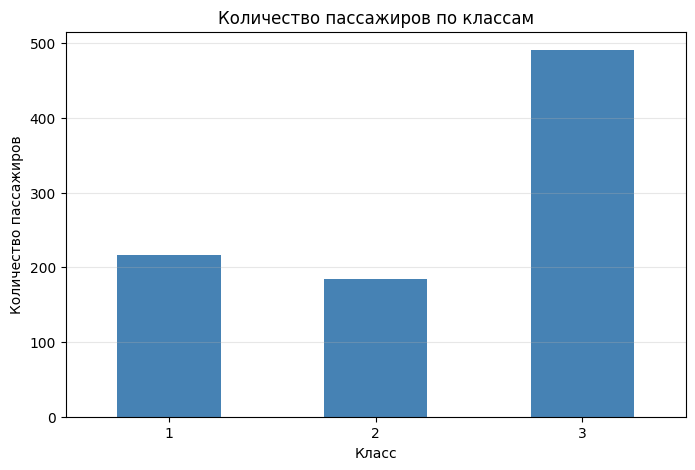

In [12]:
# График количества пассажиров по классам
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()